# 02 - 微积分基础：让模型能够“学习”

> 配套脚本：`01_math_foundations/02_calculus.py`

本 Notebook 不是对原脚本的逐行搬运，而是围绕“微积分为什么能让机器学习模型学习”重新组织的教程版。
我们会从导数的几何直觉出发，逐步走到多变量函数、链式法则、反向传播和梯度下降。

## 本 Notebook 概览

| 章节 | 内容 | 你将理解 |
|------|------|----------|
| 1 | 导数的直觉 | 变化率、切线斜率、局部线性近似 |
| 2 | 数值求导 | 如何用有限差分近似导数，以及为什么步长不能乱选 |
| 3 | 常用求导法则 | 幂函数、指数、对数、乘法、链式法则的可视化理解 |
| 4 | 偏导数与曲面 | 多变量函数中“只沿一个方向看变化” |
| 5 | 梯度 | 梯度为何指向上升最快方向，负梯度为何用于下降 |
| 6 | 链式法则与反向传播 | 从简单复合函数到单神经元的手工反向传播 |
| 7 | 梯度下降实战 | 学习率、收敛、发散、线性回归训练 |
| 8 | 总结与练习 | 常见误区、学习路线和小练习 |

**先决条件**：安装 `numpy`、`matplotlib`

```bash
pip install numpy matplotlib
```

**核心主线**：

损失函数衡量模型错得多离谱；导数/梯度告诉我们参数应该往哪里改；梯度下降把这个方向一次次应用到参数上，于是模型就“学会”了。


In [ ]:
# 环境准备
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
np.random.seed(42)

print('NumPy 版本:', np.__version__)
print('✅ 环境准备完毕')


NumPy 版本: 2.2.6
✅ 环境准备完毕


## 1. 导数的直觉：函数在某一点“正在怎么变”

对一元函数 $f(x)$，导数定义为：

$$
f'(x)=\lim_{h\to 0}\frac{f(x+h)-f(x)}{h}
$$

这句话可以拆成三层理解：

1. $f(x+h)-f(x)$：函数值变化了多少
2. 除以 $h$：平均每单位 $x$ 的变化量是多少
3. $h\to 0$：把观察窗口缩小到一个点附近，得到瞬时变化率

### 生活类比

| 场景 | 数学关系 | 含义 |
|------|----------|------|
| 位置 $s(t)$ | $v(t)=s'(t)$ | 速度 = 位置对时间的导数 |
| 速度 $v(t)$ | $a(t)=v'(t)$ | 加速度 = 速度对时间的导数 |
| 损失 $L(w)$ | $L'(w)$ | 参数改变时损失如何改变 |

在机器学习中，我们关心的常常不是“函数值是多少”，而是：

> 如果我把参数 $w$ 稍微调大一点，损失 $L$ 会变大还是变小？变得快不快？


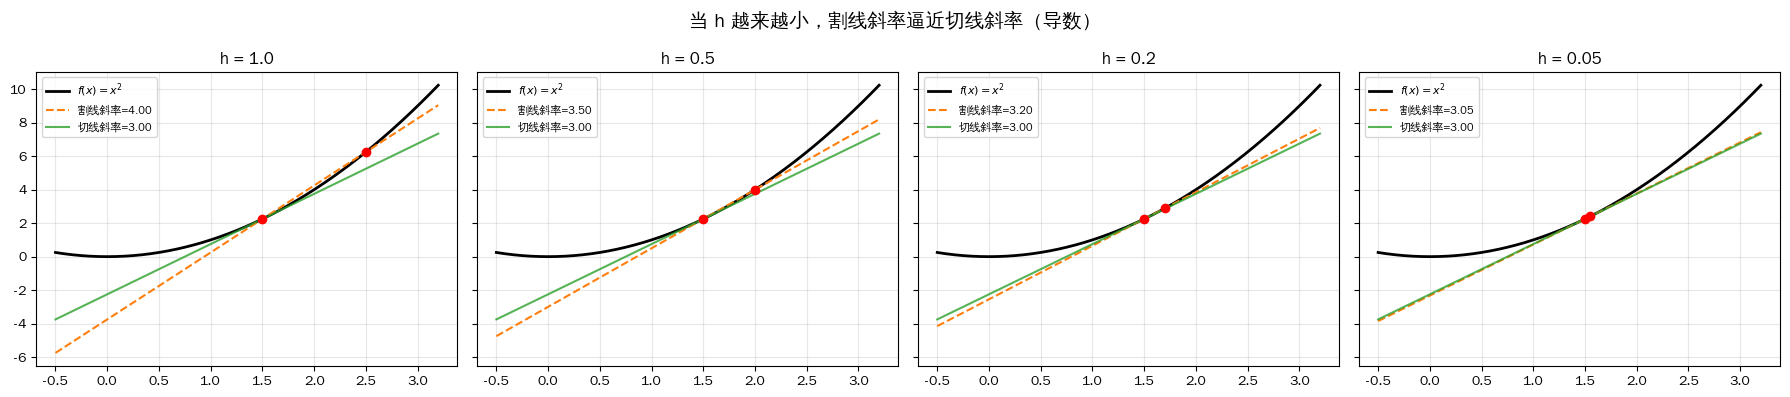

In [2]:
# 可视化：割线逐渐逼近切线

def f(x):
    return x**2

def df(x):
    return 2*x

x0 = 1.5
hs = [1.0, 0.5, 0.2, 0.05]
xs = np.linspace(-0.5, 3.2, 400)

fig, axes = plt.subplots(1, len(hs), figsize=(18, 4), sharey=True)
for ax, h in zip(axes, hs):
    slope_secant = (f(x0 + h) - f(x0)) / h
    secant_line = f(x0) + slope_secant * (xs - x0)
    tangent_line = f(x0) + df(x0) * (xs - x0)

    ax.plot(xs, f(xs), 'k', lw=2, label='$f(x)=x^2$')
    ax.plot(xs, secant_line, 'C1--', label=f'割线斜率={slope_secant:.2f}')
    ax.plot(xs, tangent_line, 'C2-', alpha=0.8, label=f'切线斜率={df(x0):.2f}')
    ax.scatter([x0, x0+h], [f(x0), f(x0+h)], color='red', zorder=3)
    ax.set_title(f'h = {h}')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle('当 h 越来越小，割线斜率逼近切线斜率（导数）', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 1.1 局部线性近似：导数是一阶“放大镜”

如果 $x$ 只发生很小的变化 $\Delta x$，函数值可以近似为：

$$
f(x+\Delta x) \approx f(x) + f'(x)\Delta x
$$

这叫**一阶泰勒近似**。它解释了为什么导数如此重要：

- 复杂函数在一个很小的局部区域里，几乎可以看成一条直线
- 这条直线的斜率就是导数
- 梯度下降本质上就是反复使用这种局部线性信息来调整参数


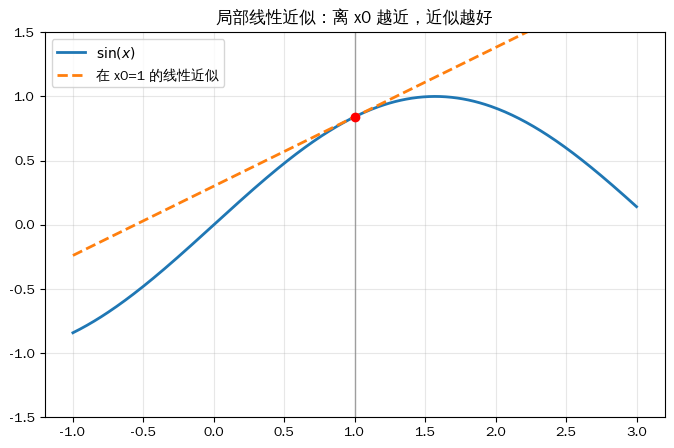

Δx= 0.5: 真实值=0.99749499, 近似值=1.11162214, 误差=1.14e-01
Δx= 0.2: 真实值=0.93203909, 近似值=0.94953145, 误差=1.75e-02
Δx=0.05: 真实值=0.86742323, 近似值=0.86848610, 误差=1.06e-03
Δx=0.01: 真实值=0.84683184, 近似值=0.84687401, 误差=4.22e-05


In [3]:
# 局部线性近似示例：sin(x) 在 x0 附近近似为一条直线
x0 = 1.0
xs = np.linspace(-1, 3, 400)
approx = np.sin(x0) + np.cos(x0) * (xs - x0)

plt.figure(figsize=(8, 5))
plt.plot(xs, np.sin(xs), label='$\sin(x)$', lw=2)
plt.plot(xs, approx, '--', label='在 x0=1 的线性近似', lw=2)
plt.axvline(x0, color='gray', lw=1, alpha=0.7)
plt.scatter([x0], [np.sin(x0)], color='red', zorder=3)
plt.ylim(-1.5, 1.5)
plt.grid(alpha=0.3)
plt.legend()
plt.title('局部线性近似：离 x0 越近，近似越好')
plt.show()

for delta in [0.5, 0.2, 0.05, 0.01]:
    true_value = np.sin(x0 + delta)
    approx_value = np.sin(x0) + np.cos(x0) * delta
    print(f'Δx={delta:>4}: 真实值={true_value:.8f}, 近似值={approx_value:.8f}, 误差={abs(true_value-approx_value):.2e}')


## 2. 数值求导：从定义出发验证导数

解析求导能得到精确公式，例如 $f(x)=x^2$ 的导数是 $2x$。
但在实际编程中，我们也常用**有限差分**来验证梯度实现是否正确。

常见差分方法：

| 方法 | 公式 | 误差量级 | 说明 |
|------|------|----------|------|
| 前向差分 | $\frac{f(x+h)-f(x)}{h}$ | $O(h)$ | 简单，但误差较大 |
| 中心差分 | $\frac{f(x+h)-f(x-h)}{2h}$ | $O(h^2)$ | 更准确，梯度检查常用 |

注意：$h$ 不是越小越好。太大时近似粗糙；太小时会受到浮点舍入误差影响。


In [4]:
def forward_diff(f, x, h=1e-5):
    return (f(x + h) - f(x)) / h

def central_diff(f, x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2*h)

# 验证几个函数的导数
examples = [
    ('x^2', lambda x: x**2, lambda x: 2*x, 3.0),
    ('x^3', lambda x: x**3, lambda x: 3*x**2, 2.0),
    ('exp(x)', np.exp, np.exp, 1.0),
    ('log(x)', np.log, lambda x: 1/x, 2.0),
    ('sin(x)', np.sin, np.cos, np.pi/4),
]

for name, func, dfunc, x in examples:
    fwd = forward_diff(func, x)
    cen = central_diff(func, x)
    exact = dfunc(x)
    print(f'{name:>7} at x={x:.4f}: exact={exact:.8f}, forward={fwd:.8f}, central={cen:.8f}')


    x^2 at x=3.0000: exact=6.00000000, forward=6.00001000, central=6.00000000
    x^3 at x=2.0000: exact=12.00000000, forward=12.00006000, central=12.00000000
 exp(x) at x=1.0000: exact=2.71828183, forward=2.71829542, central=2.71828183
 log(x) at x=2.0000: exact=0.50000000, forward=0.49999875, central=0.50000000
 sin(x) at x=0.7854: exact=0.70710678, forward=0.70710325, central=0.70710678


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

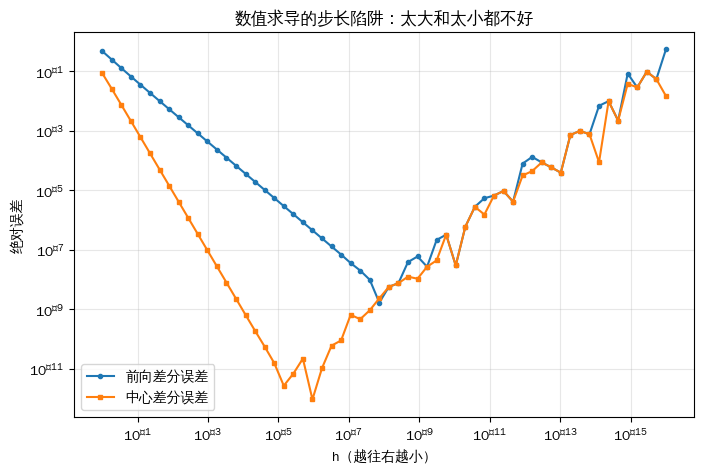

中心差分的较优 h 约为: 1.08e-06


In [5]:
# 步长 h 对数值求导误差的影响
func = np.sin
exact_grad = np.cos(1.0)
hs = np.logspace(-16, 0, 60)
forward_errors = [abs(forward_diff(func, 1.0, h) - exact_grad) for h in hs]
central_errors = [abs(central_diff(func, 1.0, h) - exact_grad) for h in hs]

plt.figure(figsize=(8, 5))
plt.loglog(hs, forward_errors, 'o-', label='前向差分误差', markersize=3)
plt.loglog(hs, central_errors, 's-', label='中心差分误差', markersize=3)
plt.gca().invert_xaxis()
plt.xlabel('h（越往右越小）')
plt.ylabel('绝对误差')
plt.title('数值求导的步长陷阱：太大和太小都不好')
plt.grid(alpha=0.3, which='both')
plt.legend()
plt.show()

best_h = hs[np.argmin(central_errors)]
print(f'中心差分的较优 h 约为: {best_h:.2e}')


## 3. 常用求导法则：不只是背公式

机器学习里最常见的函数并不多：多项式、指数、对数、sigmoid、ReLU、softmax、损失函数。
只要掌握基本规则，就可以通过组合得到复杂模型的梯度。

| 规则 | 公式 | 直觉 |
|------|------|------|
| 常数 | $(c)'=0$ | 不变的东西没有变化率 |
| 幂函数 | $(x^n)'=nx^{n-1}$ | 次方越高，远离 0 后增长越快 |
| 指数 | $(e^x)'=e^x$ | 自身就是增长率 |
| 对数 | $(\ln x)'=1/x$ | $x$ 越大，新增一点带来的相对变化越小 |
| 加法 | $(f+g)'=f'+g'$ | 变化量可以相加 |
| 乘法 | $(fg)'=f'g+fg'$ | 两个因素都在变，需要各算一次贡献 |
| 链式 | $f(g(x))'=f'(g(x))g'(x)$ | 内层变化会被外层放大或缩小 |


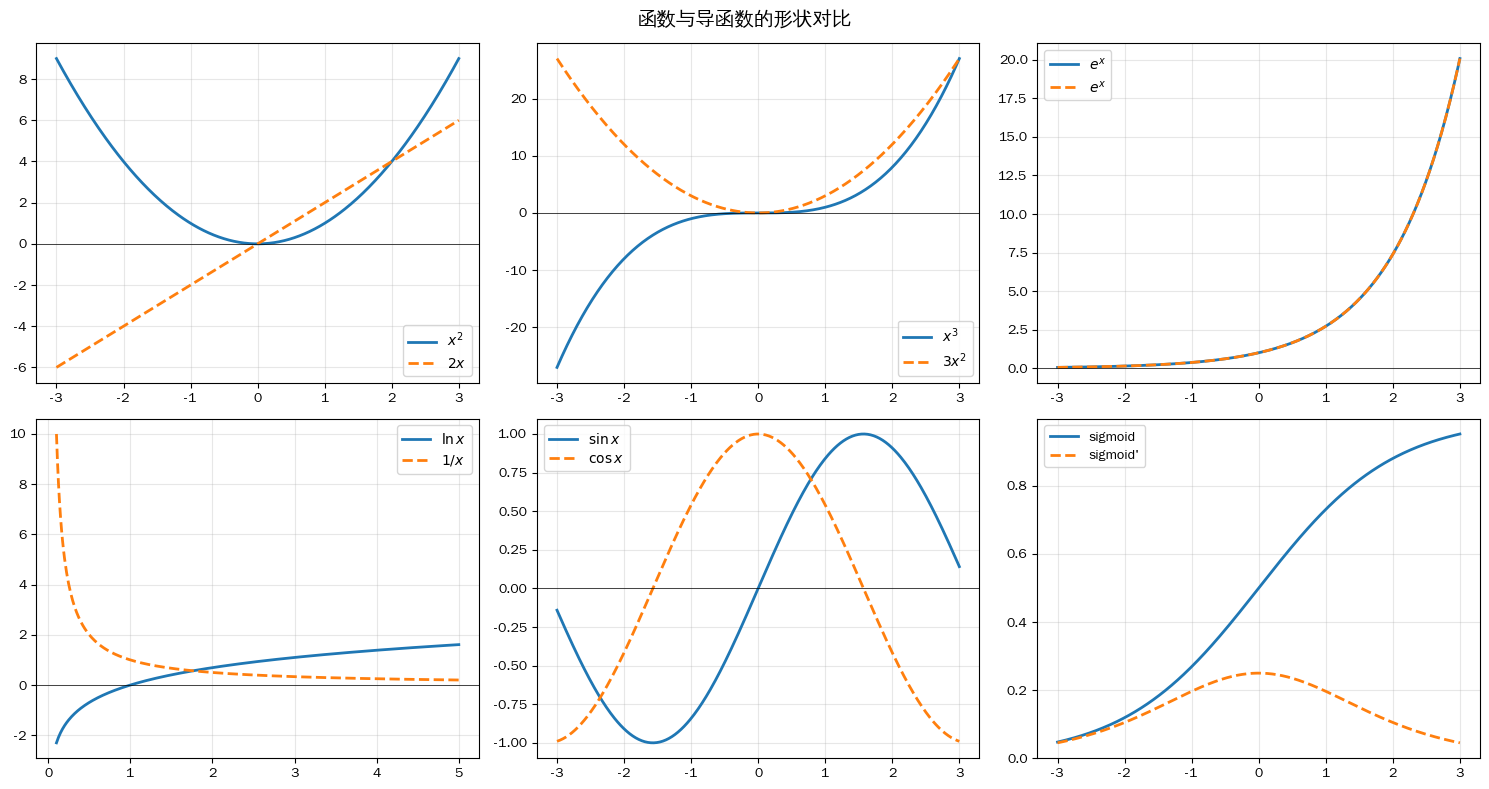

In [6]:
# 对比不同函数及其导数的形状
xs = np.linspace(-3, 3, 400)
positive_xs = np.linspace(0.1, 5, 400)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
plots = [
    (axes[0,0], xs, xs**2, 2*xs, '$x^2$', '$2x$'),
    (axes[0,1], xs, xs**3, 3*xs**2, '$x^3$', '$3x^2$'),
    (axes[0,2], xs, np.exp(xs), np.exp(xs), '$e^x$', '$e^x$'),
    (axes[1,0], positive_xs, np.log(positive_xs), 1/positive_xs, '$\ln x$', '$1/x$'),
    (axes[1,1], xs, np.sin(xs), np.cos(xs), '$\sin x$', '$\cos x$'),
    (axes[1,2], xs, 1/(1+np.exp(-xs)), (1/(1+np.exp(-xs)))*(1-1/(1+np.exp(-xs))), 'sigmoid', "sigmoid'")
]

for ax, x, y, dy, label_y, label_dy in plots:
    ax.plot(x, y, label=label_y, lw=2)
    ax.plot(x, dy, '--', label=label_dy, lw=2)
    ax.axhline(0, color='black', lw=0.5)
    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle('函数与导函数的形状对比', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.1 乘法法则：两个会变的量一起变化

如果 $y=f(x)g(x)$，那么：

$$
y'=f'(x)g(x)+f(x)g'(x)
$$

它的直觉是：

- 第一项 $f'(x)g(x)$：$f$ 变化带来的贡献，$g$ 暂时当成常数
- 第二项 $f(x)g'(x)$：$g$ 变化带来的贡献，$f$ 暂时当成常数

比如矩形面积 $A=长\times宽$。如果长和宽都在变，面积变化不是只看其中一个边，而是两边变化都要算。


y = x^2 sin(x), x=1.3
数值导数: 2.95732430
解析导数: 2.95732430
误差: 8.30e-11


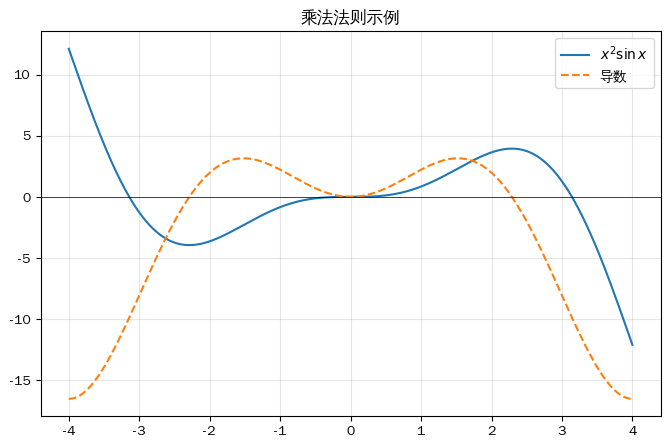

In [7]:
# 乘法法则验证：y = x^2 * sin(x)
def product_func(x):
    return x**2 * np.sin(x)

def product_grad(x):
    return 2*x*np.sin(x) + x**2*np.cos(x)

x = 1.3
num = central_diff(product_func, x)
ana = product_grad(x)
print(f'y = x^2 sin(x), x={x}')
print(f'数值导数: {num:.8f}')
print(f'解析导数: {ana:.8f}')
print(f'误差: {abs(num-ana):.2e}')

xs = np.linspace(-4, 4, 500)
plt.figure(figsize=(8, 5))
plt.plot(xs, product_func(xs), label='$x^2\sin x$')
plt.plot(xs, product_grad(xs), '--', label="导数")
plt.axhline(0, c='k', lw=0.5)
plt.grid(alpha=0.3)
plt.legend()
plt.title('乘法法则示例')
plt.show()


## 4. 偏导数：多变量函数中“只沿一个轴看变化”

现实中的模型参数通常不是一个数，而是一个向量或矩阵。例如线性模型：

$$
\hat y = w_1x_1 + w_2x_2 + b
$$

损失函数可能同时依赖 $w_1, w_2, b$。这时我们需要偏导数：

$$
\frac{\partial f}{\partial x},\quad \frac{\partial f}{\partial y}
$$

含义：

- 对 $x$ 求偏导时，把 $y$ 当常数
- 对 $y$ 求偏导时，把 $x$ 当常数
- 每个偏导数回答一个问题：“如果只改这个变量，函数会怎么变？”

示例函数：

$$
f(x,y)=x^2+2xy+y^2=(x+y)^2
$$

其偏导数为：

$$
\frac{\partial f}{\partial x}=2x+2y,\quad
\frac{\partial f}{\partial y}=2x+2y
$$


In [8]:
def f_multi(x, y):
    return x**2 + 2*x*y + y**2

def partial_x(f, x, y, h=1e-5):
    return (f(x+h, y) - f(x-h, y)) / (2*h)

def partial_y(f, x, y, h=1e-5):
    return (f(x, y+h) - f(x, y-h)) / (2*h)

x, y = 1.0, 2.0
px = partial_x(f_multi, x, y)
py = partial_y(f_multi, x, y)
exact = 2*x + 2*y

print('f(x,y) = x^2 + 2xy + y^2')
print(f'在 (x,y)=({x},{y}) 处')
print(f'∂f/∂x 数值={px:.6f}, 解析={exact:.6f}')
print(f'∂f/∂y 数值={py:.6f}, 解析={exact:.6f}')


f(x,y) = x^2 + 2xy + y^2
在 (x,y)=(1.0,2.0) 处
∂f/∂x 数值=6.000000, 解析=6.000000
∂f/∂y 数值=6.000000, 解析=6.000000


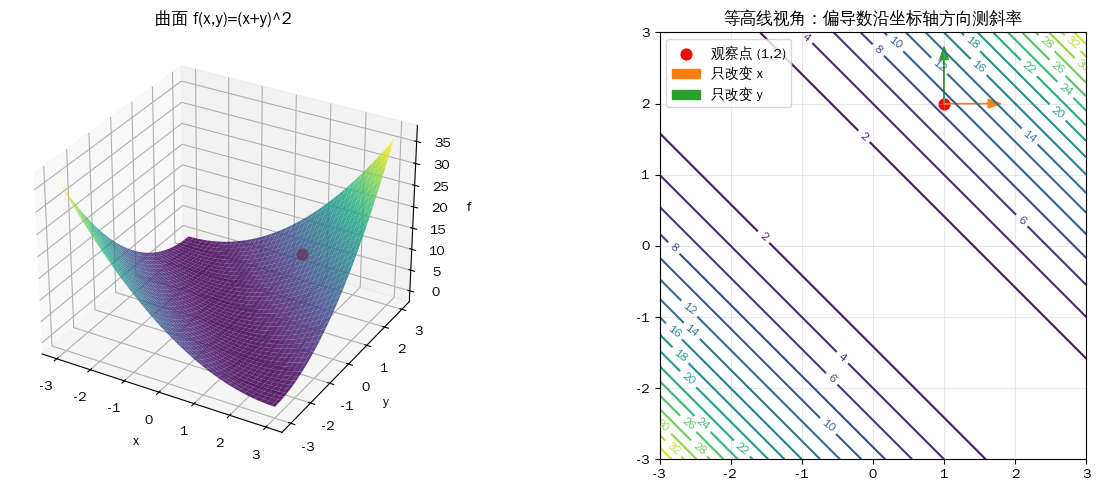

In [9]:
# 曲面 + 等高线：偏导数是在曲面上沿坐标轴方向切一刀
x = np.linspace(-3, 3, 120)
y = np.linspace(-3, 3, 120)
X, Y = np.meshgrid(x, y)
Z = X**2 + 2*X*Y + Y**2

fig = plt.figure(figsize=(14, 5))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.85, linewidth=0)
ax1.scatter([1], [2], [f_multi(1,2)], color='red', s=60)
ax1.set_title('曲面 f(x,y)=(x+y)^2')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f')

ax2 = fig.add_subplot(1, 2, 2)
cont = ax2.contour(X, Y, Z, levels=20, cmap='viridis')
ax2.clabel(cont, inline=True, fontsize=8)
ax2.scatter([1], [2], color='red', s=60, label='观察点 (1,2)')
ax2.arrow(1, 2, 0.8, 0, head_width=0.12, color='C1', length_includes_head=True, label='只改变 x')
ax2.arrow(1, 2, 0, 0.8, head_width=0.12, color='C2', length_includes_head=True, label='只改变 y')
ax2.set_aspect('equal')
ax2.grid(alpha=0.3)
ax2.legend()
ax2.set_title('等高线视角：偏导数沿坐标轴方向测斜率')
plt.tight_layout()
plt.show()


### 4.1 偏导数与“切片”

把二元函数 $f(x,y)$ 想象成一座山。

- 固定 $y=2$，只让 $x$ 变化，相当于沿东西方向切一刀，看这条截线的斜率
- 固定 $x=1$，只让 $y$ 变化，相当于沿南北方向切一刀，看另一条截线的斜率

偏导数只是沿坐标轴的斜率。下一节的**梯度**会把这些坐标轴方向的斜率合成一个向量，告诉我们真正上升最快的方向。


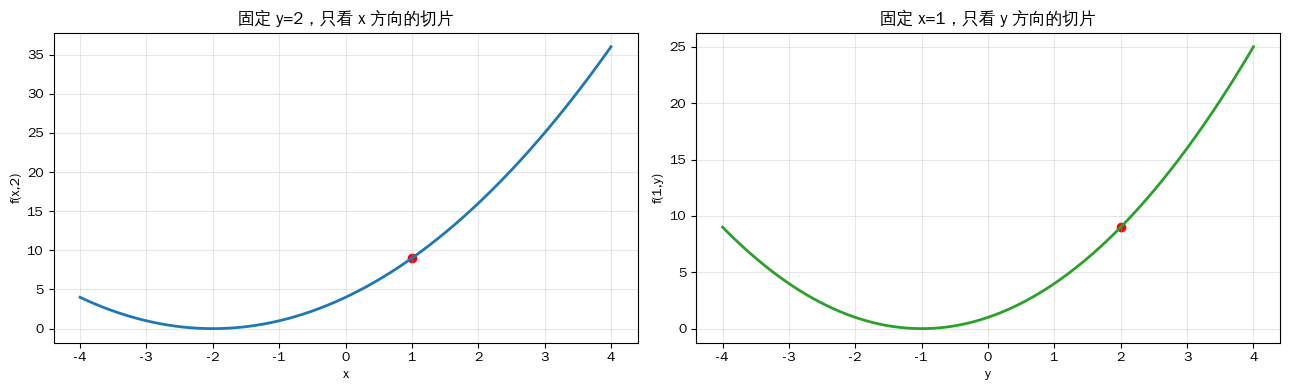

In [10]:
# 固定一个变量看函数切片
x_line = np.linspace(-4, 4, 400)
y_fixed = 2.0
y_line = np.linspace(-4, 4, 400)
x_fixed = 1.0

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(x_line, f_multi(x_line, y_fixed), lw=2)
axes[0].scatter([x_fixed], [f_multi(x_fixed, y_fixed)], color='red')
axes[0].set_title('固定 y=2，只看 x 方向的切片')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x,2)')
axes[0].grid(alpha=0.3)

axes[1].plot(y_line, f_multi(x_fixed, y_line), lw=2, color='C2')
axes[1].scatter([y_fixed], [f_multi(x_fixed, y_fixed)], color='red')
axes[1].set_title('固定 x=1，只看 y 方向的切片')
axes[1].set_xlabel('y')
axes[1].set_ylabel('f(1,y)')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 5. 梯度：所有偏导数组成的方向指示器

对于多变量函数：

$$
f(x_1,x_2,\dots,x_n)
$$

梯度定义为：

$$
\nabla f = \left[\frac{\partial f}{\partial x_1},\frac{\partial f}{\partial x_2},\dots,\frac{\partial f}{\partial x_n}\right]
$$

关键直觉：

1. 梯度是一个向量
2. 梯度方向是函数上升最快的方向
3. 负梯度方向是函数下降最快的方向
4. 梯度的长度表示局部变化有多陡

因此机器学习里常见的参数更新公式是：

$$
\theta_{new}=\theta_{old}-\eta \nabla L(\theta)
$$

其中 $\eta$ 是学习率。


In [11]:
def bowl(params):
    x, y = params
    return x**2 + y**2

def grad_bowl(params):
    x, y = params
    return np.array([2*x, 2*y])

def numerical_gradient(f, params, h=1e-5):
    grad = np.zeros_like(params, dtype=float)
    for i in range(len(params)):
        p_plus = params.copy().astype(float)
        p_minus = params.copy().astype(float)
        p_plus[i] += h
        p_minus[i] -= h
        grad[i] = (f(p_plus) - f(p_minus)) / (2*h)
    return grad

params = np.array([3.0, 4.0])
ana = grad_bowl(params)
num = numerical_gradient(bowl, params)
print(f'f(x,y)=x^2+y^2 在 {params} 处')
print(f'解析梯度: {ana}')
print(f'数值梯度: {num}')
print(f'梯度长度: {np.linalg.norm(ana):.4f}')


f(x,y)=x^2+y^2 在 [3. 4.] 处
解析梯度: [6. 8.]
数值梯度: [6. 8.]
梯度长度: 10.0000


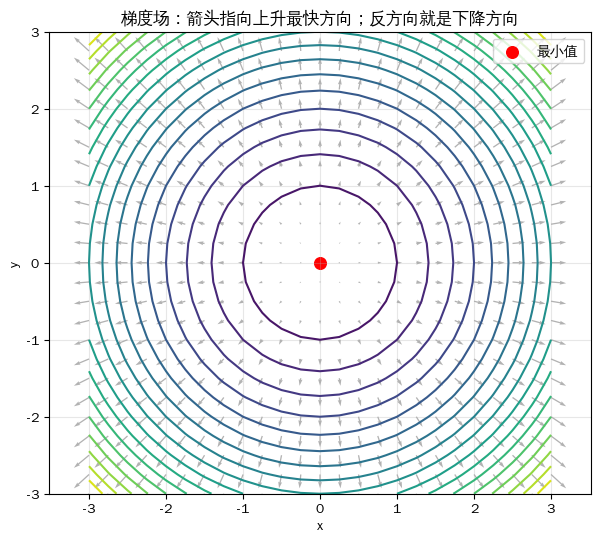

In [12]:
# 梯度场：每个箭头都指向函数上升最快的方向
x = np.linspace(-3, 3, 25)
y = np.linspace(-3, 3, 25)
X, Y = np.meshgrid(x, y)
Z = X**2 + Y**2
U, V = 2*X, 2*Y

plt.figure(figsize=(7, 6))
plt.contour(X, Y, Z, levels=20, cmap='viridis')
plt.quiver(X, Y, U, V, color='gray', alpha=0.6)
plt.scatter([0], [0], color='red', s=70, label='最小值')
plt.title('梯度场：箭头指向上升最快方向；反方向就是下降方向')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


### 5.1 方向导数：为什么梯度是“上升最快”方向？

如果沿单位方向 $u$ 前进一点，函数变化率叫方向导数：

$$
D_u f = \nabla f \cdot u = ||\nabla f||\,||u||\cos\theta
$$

因为 $u$ 是单位向量，$||u||=1$，所以：

$$
D_u f = ||\nabla f||\cos\theta
$$

当 $\theta=0$ 时，$\cos\theta=1$，方向导数最大。
也就是说：方向 $u$ 与梯度同向时，函数增长最快。


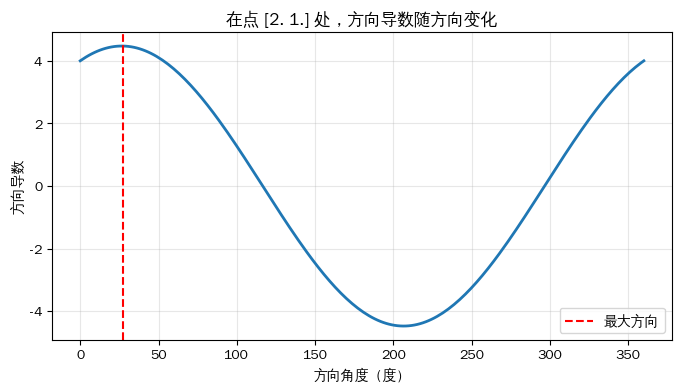

梯度 = [4. 2.], 梯度方向角度 ≈ 26.57°
扫描得到最大方向角度 ≈ 27.14°


In [13]:
# 用不同方向验证方向导数
point = np.array([2.0, 1.0])
g = grad_bowl(point)
g_unit = g / np.linalg.norm(g)
angles = np.linspace(0, 2*np.pi, 200)
directional_derivatives = []

for a in angles:
    u = np.array([np.cos(a), np.sin(a)])
    directional_derivatives.append(g @ u)

directional_derivatives = np.array(directional_derivatives)
max_idx = np.argmax(directional_derivatives)

plt.figure(figsize=(8, 4))
plt.plot(np.degrees(angles), directional_derivatives, lw=2)
plt.axvline(np.degrees(angles[max_idx]), color='red', linestyle='--', label='最大方向')
plt.xlabel('方向角度（度）')
plt.ylabel('方向导数')
plt.title(f'在点 {point} 处，方向导数随方向变化')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print(f'梯度 = {g}, 梯度方向角度 ≈ {np.degrees(np.arctan2(g[1], g[0])):.2f}°')
print(f'扫描得到最大方向角度 ≈ {np.degrees(angles[max_idx]):.2f}°')


## 6. 链式法则：反向传播的数学核心

如果函数是嵌套的：

$$
y=f(g(x))
$$

那么导数是：

$$
\frac{dy}{dx}=f'(g(x))g'(x)
$$

更适合神经网络的写法：

$$
\frac{dy}{dx}=\frac{dy}{du}\frac{du}{dx},\quad u=g(x)
$$

直觉：变化率会沿计算链条传递。

- $x$ 改变一点，会让 $u$ 改变 $du/dx$ 倍
- $u$ 改变一点，会让 $y$ 改变 $dy/du$ 倍
- 所以 $x$ 对 $y$ 的总影响就是两段影响相乘

神经网络正是很多函数的复合：

$$
output=f_3(f_2(f_1(input)))
$$

反向传播就是从输出层开始，沿着计算图反方向应用链式法则。


In [14]:
# 链式法则示例：y = (2x + 1)^3

def composite(x):
    return (2*x + 1)**3

def composite_grad(x):
    # u = 2x+1, y=u^3 => dy/dx = 3u^2 * 2
    return 6*(2*x + 1)**2

x = 2.0
num = central_diff(composite, x)
ana = composite_grad(x)
print('y = (2x+1)^3')
print('令 u=2x+1, y=u^3')
print('dy/dx = dy/du · du/dx = 3u^2 · 2 = 6(2x+1)^2')
print(f'在 x={x} 处：数值导数={num:.6f}, 解析导数={ana:.6f}')


y = (2x+1)^3
令 u=2x+1, y=u^3
dy/dx = dy/du · du/dx = 3u^2 · 2 = 6(2x+1)^2
在 x=2.0 处：数值导数=150.000000, 解析导数=150.000000


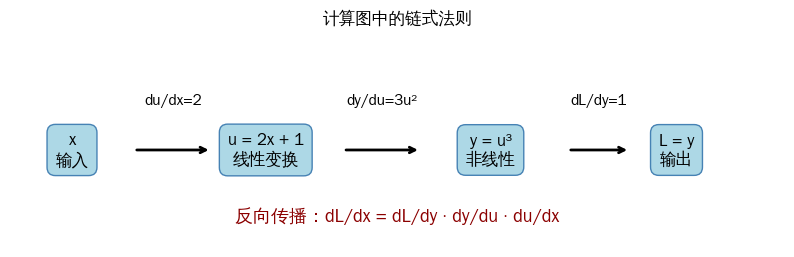

In [15]:
# 计算图可视化：x -> u -> y
fig, ax = plt.subplots(figsize=(10, 2.8))
ax.axis('off')
boxes = [
    (0.08, 0.45, 'x\n输入'),
    (0.33, 0.45, 'u = 2x + 1\n线性变换'),
    (0.62, 0.45, 'y = u³\n非线性'),
    (0.86, 0.45, 'L = y\n输出')
]
for x0, y0, text in boxes:
    ax.text(x0, y0, text, ha='center', va='center', fontsize=12,
            bbox=dict(boxstyle='round,pad=0.5', fc='lightblue', ec='steelblue'))
for start, end, label in [(0.16, 0.26, 'du/dx=2'), (0.43, 0.53, 'dy/du=3u²'), (0.72, 0.80, 'dL/dy=1')]:
    ax.annotate('', xy=(end, 0.45), xytext=(start, 0.45), arrowprops=dict(arrowstyle='->', lw=2))
    ax.text((start+end)/2, 0.66, label, ha='center', fontsize=11)
ax.text(0.5, 0.12, '反向传播：dL/dx = dL/dy · dy/du · du/dx', ha='center', fontsize=13, color='darkred')
plt.title('计算图中的链式法则', fontweight='bold')
plt.show()


### 6.1 手工反向传播：一个单神经元

考虑一个非常小的神经网络：

$$
z=wx+b
$$

$$
a=\sigma(z)=\frac{1}{1+e^{-z}}
$$

$$
L=(a-y)^2
$$

目标：求 $\partial L/\partial w$。

链式法则给出：

$$
\frac{\partial L}{\partial w}
=\frac{\partial L}{\partial a}\cdot
 \frac{\partial a}{\partial z}\cdot
 \frac{\partial z}{\partial w}
$$

各部分为：

$$
\frac{\partial L}{\partial a}=2(a-y),\quad
\frac{\partial a}{\partial z}=a(1-a),\quad
\frac{\partial z}{\partial w}=x
$$


In [16]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 初始值
w = 0.5
b = 0.1
x = 2.0
y_true = 1.0

# 前向传播
z = w*x + b
a = sigmoid(z)
L = (a - y_true)**2

# 反向传播
dL_da = 2*(a - y_true)
da_dz = a*(1 - a)
dz_dw = x
dz_db = 1.0

dL_dw = dL_da * da_dz * dz_dw
dL_db = dL_da * da_dz * dz_db

print('前向传播：')
print(f'  z = w*x+b = {z:.6f}')
print(f'  a = sigmoid(z) = {a:.6f}')
print(f'  L = (a-y)^2 = {L:.6f}')

print('\n反向传播：')
print(f'  dL/da = {dL_da:.6f}')
print(f'  da/dz = {da_dz:.6f}')
print(f'  dz/dw = {dz_dw:.6f}')
print(f'  dL/dw = {dL_dw:.6f}')
print(f'  dL/db = {dL_db:.6f}')

# 数值梯度验证
def loss_wrt_w(w_value):
    return (sigmoid(w_value*x + b) - y_true)**2

def loss_wrt_b(b_value):
    return (sigmoid(w*x + b_value) - y_true)**2

num_dw = central_diff(loss_wrt_w, w)
num_db = central_diff(loss_wrt_b, b)
print('\n数值梯度检查：')
print(f'  dL/dw: 解析={dL_dw:.8f}, 数值={num_dw:.8f}, 误差={abs(dL_dw-num_dw):.2e}')
print(f'  dL/db: 解析={dL_db:.8f}, 数值={num_db:.8f}, 误差={abs(dL_db-num_db):.2e}')


前向传播：
  z = w*x+b = 1.100000
  a = sigmoid(z) = 0.750260
  L = (a-y)^2 = 0.062370

反向传播：
  dL/da = -0.499480
  da/dz = 0.187370
  dz/dw = 2.000000
  dL/dw = -0.187175
  dL/db = -0.093587

数值梯度检查：
  dL/dw: 解析=-0.18717494, 数值=-0.18717494, 误差=1.17e-11
  dL/db: 解析=-0.09358747, 数值=-0.09358747, 误差=6.28e-13


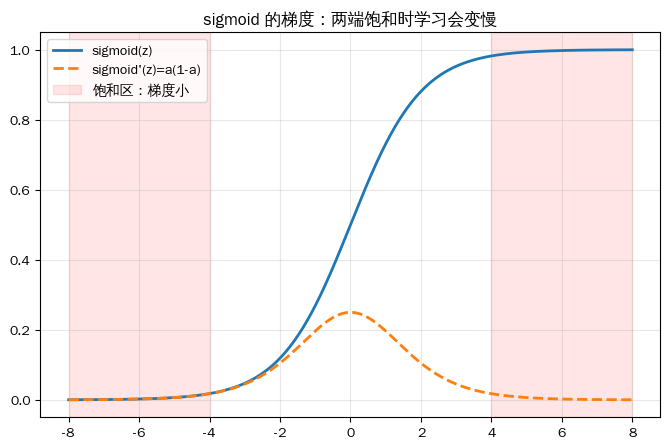

sigmoid 导数最大值约为 0.250，出现在 z≈0


In [17]:
# sigmoid 与其导数：饱和区梯度很小
zs = np.linspace(-8, 8, 500)
as_ = sigmoid(zs)
grads = as_ * (1 - as_)

plt.figure(figsize=(8, 5))
plt.plot(zs, as_, label='sigmoid(z)', lw=2)
plt.plot(zs, grads, '--', label="sigmoid'(z)=a(1-a)", lw=2)
plt.axvspan(-8, -4, alpha=0.1, color='red', label='饱和区：梯度小')
plt.axvspan(4, 8, alpha=0.1, color='red')
plt.grid(alpha=0.3)
plt.legend()
plt.title('sigmoid 的梯度：两端饱和时学习会变慢')
plt.show()
print(f'sigmoid 导数最大值约为 {grads.max():.3f}，出现在 z≈0')


## 7. 梯度下降：让参数沿负梯度方向移动

梯度下降的更新公式：

$$
\theta \leftarrow \theta - \eta\nabla L(\theta)
$$

其中：

- $\theta$：模型参数
- $L$：损失函数
- $\nabla L$：损失对参数的梯度
- $\eta$：学习率，控制每一步走多远

直观比喻：闭着眼下山。
你摸到脚下坡度最陡的上坡方向（梯度），于是往反方向走一小步。


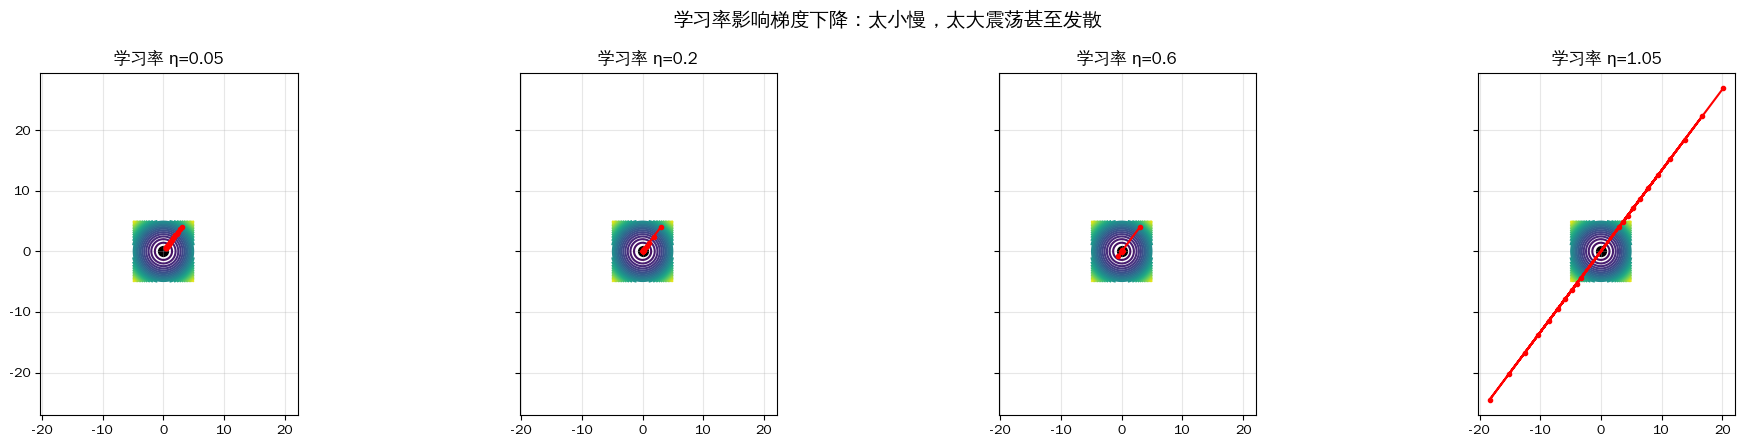

η=0.05: 最终点=[0.36472996 0.48630662], f=0.369522
η=0.2 : 最终点=[0.00010968 0.00014625], f=0.000000
η=0.6 : 最终点=[3.145728e-14 4.194304e-14], f=0.000000
η=1.05: 最终点=[20.18249985 26.9099998 ], f=1131.481389


In [18]:
# 在碗形函数 f(x,y)=x^2+y^2 上演示梯度下降路径
def gradient_descent_path(start, lr=0.1, steps=30):
    params = np.array(start, dtype=float)
    path = [params.copy()]
    for _ in range(steps):
        params = params - lr * grad_bowl(params)
        path.append(params.copy())
    return np.array(path)

starts = np.array([3.0, 4.0])
learning_rates = [0.05, 0.2, 0.6, 1.05]

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), sharex=True, sharey=True)
x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x, y)
Z = X**2 + Y**2

for ax, lr in zip(axes, learning_rates):
    path = gradient_descent_path(starts, lr=lr, steps=20)
    ax.contour(X, Y, Z, levels=25, cmap='viridis')
    ax.plot(path[:,0], path[:,1], 'o-', color='red', markersize=3)
    ax.scatter([0], [0], color='black', s=50, label='最小值')
    ax.set_title(f'学习率 η={lr}')
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)

plt.suptitle('学习率影响梯度下降：太小慢，太大震荡甚至发散', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

for lr in learning_rates:
    path = gradient_descent_path(starts, lr=lr, steps=20)
    print(f'η={lr:<4}: 最终点={path[-1]}, f={bowl(path[-1]):.6f}')


### 7.1 线性回归训练：用梯度下降拟合一条直线

我们用一个最简单的模型：

$$
\hat y = wx+b
$$

损失函数使用均方误差：

$$
L=\frac{1}{n}\sum_{i=1}^{n}(\hat y_i-y_i)^2
$$

对参数求导：

$$
\frac{\partial L}{\partial w}=\frac{2}{n}\sum_i(\hat y_i-y_i)x_i
$$

$$
\frac{\partial L}{\partial b}=\frac{2}{n}\sum_i(\hat y_i-y_i)
$$

这就是机器学习训练循环最核心的样子：

1. 前向传播：算预测值
2. 计算损失：预测与真实差多少
3. 反向传播：算梯度
4. 参数更新：沿负梯度方向移动


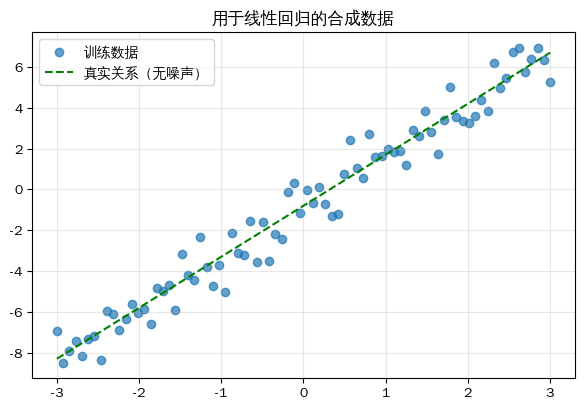

In [19]:
# 生成一批带噪声的线性数据
np.random.seed(7)
n = 80
X = np.linspace(-3, 3, n)
y = 2.5 * X - 0.8 + np.random.randn(n) * 0.8

plt.figure(figsize=(7, 4.5))
plt.scatter(X, y, alpha=0.7, label='训练数据')
plt.plot(X, 2.5*X - 0.8, 'g--', label='真实关系（无噪声）')
plt.grid(alpha=0.3)
plt.legend()
plt.title('用于线性回归的合成数据')
plt.show()


In [20]:
# 从零实现梯度下降训练线性回归
w = 0.0
b = 0.0
lr = 0.05
steps = 120
history = []
param_path = []

for step in range(steps):
    y_pred = w * X + b
    errors = y_pred - y
    loss = np.mean(errors**2)

    dL_dw = 2 * np.mean(errors * X)
    dL_db = 2 * np.mean(errors)

    w -= lr * dL_dw
    b -= lr * dL_db

    history.append(loss)
    param_path.append([w, b])

    if step < 5 or step in [9, 29, 59, 119]:
        print(f'第 {step+1:3d} 步: loss={loss:.4f}, w={w:.4f}, b={b:.4f}, |grad|={np.sqrt(dL_dw**2+dL_db**2):.4f}')

print('\n训练完成')
print(f'学习到的参数: w={w:.4f}, b={b:.4f}')
print('真实参数约为: w=2.5, b=-0.8')


第   1 步: loss=20.7199, w=0.7702, b=-0.0850, |grad|=15.4981
第   2 步: loss=10.5423, w=1.3035, b=-0.1614, |grad|=10.7754
第   3 步: loss=5.6176, w=1.6728, b=-0.2303, |grad|=7.5126
第   4 步: loss=3.2199, w=1.9285, b=-0.2922, |grad|=5.2616
第   5 步: loss=2.0406, w=2.1055, b=-0.3479, |grad|=3.7121
第  10 步: loss=0.8450, w=2.4406, b=-0.5534, |grad|=0.8666
第  30 步: loss=0.7125, w=2.5040, b=-0.8136, |grad|=0.0800
第  60 步: loss=0.7109, w=2.5041, b=-0.8481, |grad|=0.0034
第 120 步: loss=0.7109, w=2.5041, b=-0.8497, |grad|=0.0000

训练完成
学习到的参数: w=2.5041, b=-0.8497
真实参数约为: w=2.5, b=-0.8


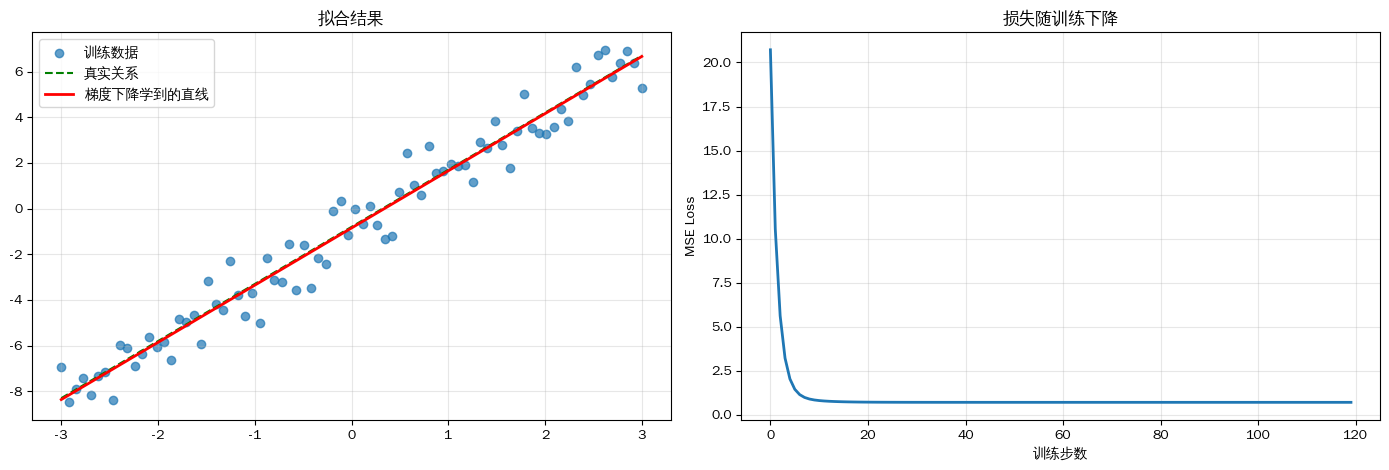

In [21]:
# 可视化训练结果与 loss 曲线
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

axes[0].scatter(X, y, alpha=0.7, label='训练数据')
axes[0].plot(X, 2.5*X - 0.8, 'g--', label='真实关系')
axes[0].plot(X, w*X + b, 'r-', lw=2, label='梯度下降学到的直线')
axes[0].grid(alpha=0.3)
axes[0].legend()
axes[0].set_title('拟合结果')

axes[1].plot(history, lw=2)
axes[1].set_xlabel('训练步数')
axes[1].set_ylabel('MSE Loss')
axes[1].set_title('损失随训练下降')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


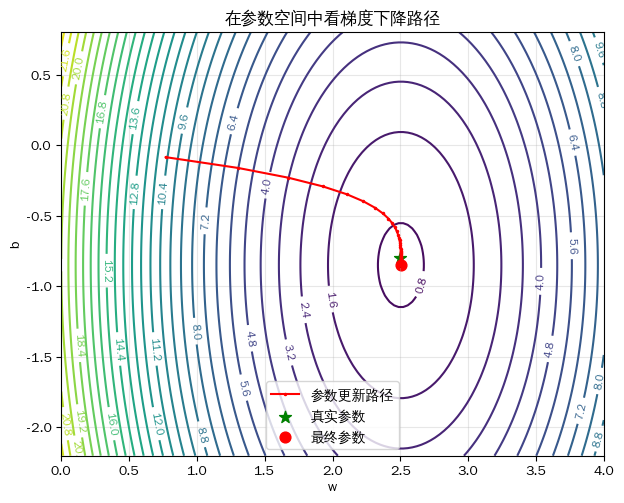

In [22]:
# 参数空间中的损失地形与优化路径
w_values = np.linspace(0, 4, 120)
b_values = np.linspace(-2.2, 0.8, 120)
W, B = np.meshgrid(w_values, b_values)
Loss = np.zeros_like(W)
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        Loss[i, j] = np.mean((W[i, j]*X + B[i, j] - y)**2)

path = np.array(param_path)
plt.figure(figsize=(7, 5.5))
cont = plt.contour(W, B, Loss, levels=30, cmap='viridis')
plt.clabel(cont, inline=True, fontsize=8)
plt.plot(path[:,0], path[:,1], 'r.-', markersize=3, label='参数更新路径')
plt.scatter([2.5], [-0.8], color='green', s=80, marker='*', label='真实参数')
plt.scatter([w], [b], color='red', s=60, label='最终参数')
plt.xlabel('w')
plt.ylabel('b')
plt.title('在参数空间中看梯度下降路径')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## 8. 补充：非凸函数、局部极小值与鞍点

线性回归的损失是一个凸“碗”，梯度下降比较容易理解。
但深度神经网络的损失地形通常非常复杂，可能包含：

- 局部极小值：附近都比它高，但不一定是全局最低
- 鞍点：某些方向上升，某些方向下降，梯度可能接近 0
- 平坦区域：梯度很小，学习缓慢
- 陡峭区域：学习率太大容易震荡

下面用一个简单函数观察复杂地形：

$$
f(x,y)=0.2(x^2+y^2)+\sin(3x)\cos(3y)
$$


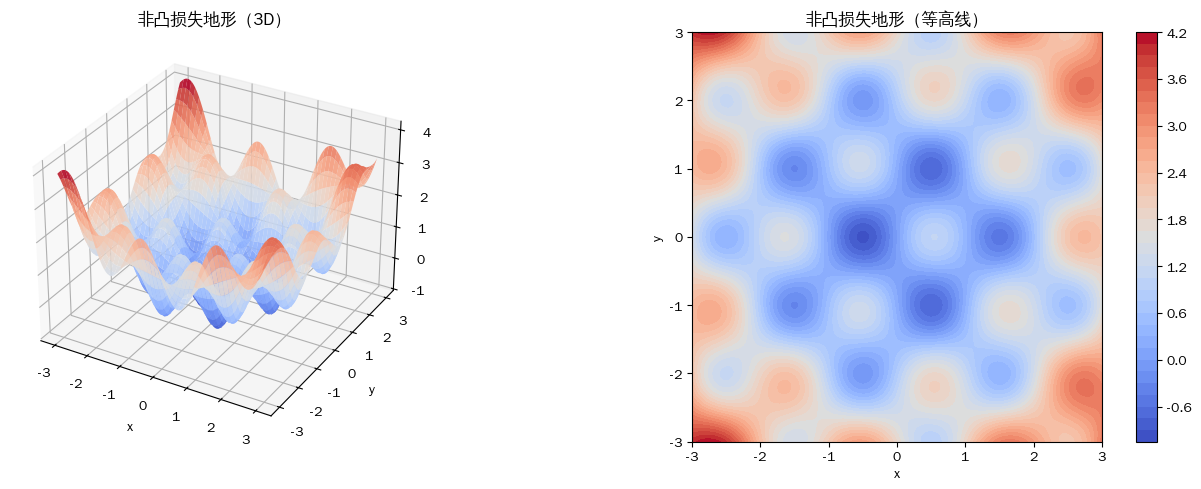

In [23]:
def nonconvex(x, y):
    return 0.2*(x**2 + y**2) + np.sin(3*x)*np.cos(3*y)

x = np.linspace(-3, 3, 250)
y = np.linspace(-3, 3, 250)
Xg, Yg = np.meshgrid(x, y)
Zg = nonconvex(Xg, Yg)

fig = plt.figure(figsize=(14, 5))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(Xg, Yg, Zg, cmap='coolwarm', alpha=0.9, linewidth=0)
ax1.set_title('非凸损失地形（3D）')
ax1.set_xlabel('x')
ax1.set_ylabel('y')

ax2 = fig.add_subplot(1, 2, 2)
cont = ax2.contourf(Xg, Yg, Zg, levels=40, cmap='coolwarm')
plt.colorbar(cont, ax=ax2)
ax2.set_aspect('equal')
ax2.set_title('非凸损失地形（等高线）')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
plt.tight_layout()
plt.show()


## 9. 常见误区与检查清单

### 常见误区

| 误区 | 正确理解 |
|------|----------|
| 导数就是函数值 | 导数是函数值的变化率，不是函数值本身 |
| 梯度一定指向最小值 | 梯度指向上升最快方向；负梯度才用于下降 |
| 学习率越大越快 | 太大可能震荡或发散 |
| 数值求导 h 越小越准 | 太小会出现浮点舍入误差 |
| 偏导数等于梯度 | 偏导数是一个方向上的变化率，梯度是所有偏导组成的向量 |
| 反向传播很神秘 | 反向传播就是计算图上的链式法则 |

### 梯度检查建议

实现自己的模型或损失函数时，可以用中心差分检查梯度：

$$
\frac{\partial L}{\partial \theta_i}\approx
\frac{L(\theta_i+h)-L(\theta_i-h)}{2h}
$$

如果解析梯度和数值梯度相差很大，通常说明反向传播公式或矩阵维度有问题。


## 10. 本节总结与练习

### 关键要点

1. **导数**：一元函数的瞬时变化率；几何上是切线斜率
2. **数值求导**：用有限差分近似导数；中心差分更适合梯度检查
3. **偏导数**：多变量函数中只改变一个变量时的变化率
4. **梯度**：所有偏导数组成的向量，指向函数上升最快方向
5. **链式法则**：复合函数求导规则，是反向传播的数学基础
6. **梯度下降**：沿负梯度方向更新参数，使损失逐步减小
7. **学习率**：控制步长；过小慢，过大不稳定

### 与 AI 的连接

机器学习训练过程可以压缩成一句话：

> 用损失函数衡量错误，用梯度指出修改方向，用梯度下降不断更新参数。

### 练习

1. 写出 $f(x)=\ln(1+e^x)$ 的导数，并用数值求导验证。
2. 对 $f(x,y)=x^2+xy+3y^2$ 求梯度，并画出等高线与梯度场。
3. 修改线性回归实验的学习率，观察 loss 曲线何时震荡或发散。
4. 把线性回归扩展成二元输入：$\hat y=w_1x_1+w_2x_2+b$，从零实现梯度下降。

下一节建议学习：概率与统计 —— 理解数据中的不确定性。
